In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg

from multipred.plotting import barplot_morey, analyze_attention_ROI, plot_decoding_nvoxels

In [2]:
PROJECT_PATH = "/media/wiseman/tocho/multipred-fmri"
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "A1"

## Comparing decoding across ROI sizes

In [3]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "a_pred", save_fig=False)

FileNotFoundError: [Errno 2] No such file or directory: '/media/wiseman/tocho/multipred-fmri/data/derivatives/decoding_data/A1_50/balanced_group_data.csv'

## Analyze specific ROIs

In [7]:
ROI = "A1"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

### Attention * visual prediction

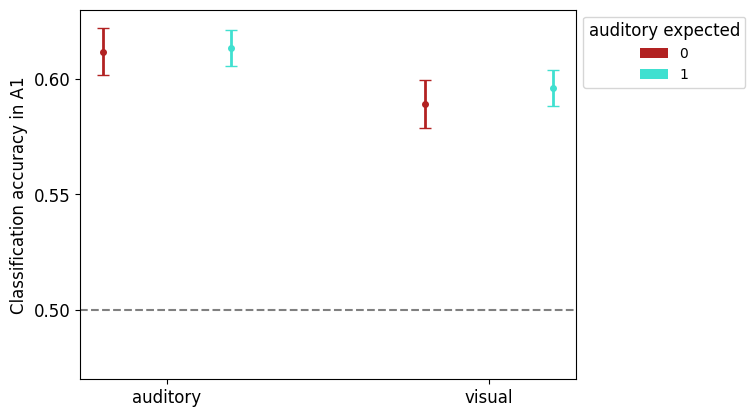

In [8]:
y = "correct"
x = "modality"
hue = "a_pred"
id = "subj"
dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
barplot_morey(dat, x, y, hue, "auditory expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False)
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.ylim(0.47, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--")

In [9]:
df["correct"].mean()

np.float64(0.6026104166666667)

In [10]:
df.groupby("modality")["correct"].mean()

modality
auditory    0.612667
visual      0.592554
Name: correct, dtype: float64

In [11]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,0.010113,1,24,0.010113,4.878311,0.036992,0.036992,0.019245,1.0
1,a_pred,0.000470,1,24,0.000470,0.299112,0.589489,0.589489,0.000912,1.0
2,modality * a_pred,0.000178,1,24,0.000178,0.069298,0.794609,0.794609,0.000346,1.0


In [7]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,2.208690,24.0,two-sided,0.036992,NaN,NaN,1.628,0.300786
1,a_pred,-,0,1,True,True,-0.546911,24.0,two-sided,0.589489,NaN,NaN,0.242,-0.065826
2,modality * a_pred,auditory,0,1,True,True,-0.131688,24.0,two-sided,0.896329,0.896329,fdr_bh,0.213,-0.021474
3,modality * a_pred,visual,0,1,True,True,-0.535165,24.0,two-sided,0.597460,0.896329,fdr_bh,0.24,-0.098543


### Multimodal analyses

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean

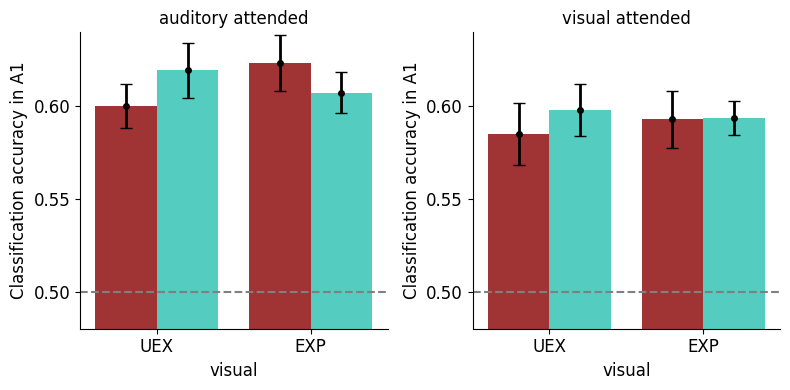

In [5]:
y = "correct"
x = "v_pred"
hue = "a_pred"
id = "subj"
ROI = "A1"
save_fig = True
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "auditory expected", id, ROI, save_fig, ylim, yticks
)

In [9]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,v_pred,0.000761,1,24,0.000761,0.156339,0.696042,0.696042,0.000968,1.0
1,auditory attended,1,a_pred,0.000069,1,24,0.000069,0.017342,0.896329,0.896329,0.000088,1.0
2,auditory attended,2,v_pred * a_pred,0.007671,1,24,0.007671,1.702688,0.204310,0.204310,0.009675,1.0
3,visual attended,0,v_pred,0.000083,1,24,0.000083,0.013400,0.908807,0.908807,0.000115,1.0
4,visual attended,1,a_pred,0.001228,1,24,0.001228,0.286402,0.597460,0.597460,0.001690,1.0
5,visual attended,2,v_pred * a_pred,0.000893,1,24,0.000893,0.202799,0.656513,0.656513,0.001229,1.0


In [10]:
posthoc_df

,level_0,level_1,Contrast,v_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,auditory attended,0,v_pred,-,0,1,True,True,-0.395397,24.0,two-sided,0.696042,NaN,NaN,0.226,-0.069801
1,auditory attended,1,a_pred,-,0,1,True,True,-0.131688,24.0,two-sided,0.896329,NaN,NaN,0.213,-0.021474
2,auditory attended,2,v_pred * a_pred,0,0,1,True,True,-1.029009,24.0,two-sided,0.313735,0.393839,fdr_bh,0.339,-0.185104
3,auditory attended,3,v_pred * a_pred,1,0,1,True,True,0.868284,24.0,two-sided,0.393839,0.393839,fdr_bh,0.297,0.202208
4,visual attended,0,v_pred,-,0,1,True,True,-0.115759,24.0,two-sided,0.908807,NaN,NaN,0.212,-0.024486
5,visual attended,1,a_pred,-,0,1,True,True,-0.535165,24.0,two-sided,0.597460,NaN,NaN,0.24,-0.098543
6,visual attended,2,v_pred * a_pred,0,0,1,True,True,-0.603020,24.0,two-sided,0.552152,0.946417,fdr_bh,0.249,-0.124215
7,visual attended,3,v_pred * a_pred,1,0,1,True,True,-0.067914,24.0,two-sided,0.946417,0.946417,fdr_bh,0.211,-0.015123
